# DL Notebook 1 - PZT damage detection (supervised binary classification)

**Problem type:** *supervised binary classification* of 1-D guided-wave signals.
**Question:** given a single PZT pitch-catch path waveform, is the plate **healthy** (baseline) or
**damaged** (magnet present)?

**Why this demo:** it is the simplest, most defensible "deep learning works on our data" result. The full
project goal is damage *localization* (a heatmap), which needs many damage instances; here, with one
specimen, detection is the trainable task. It de-risks the PZT branch of Papers 1-2.

**Data (Dataset 1):**
- Healthy class: off-diagonal paths from `test_avg64`, `test1_avg64`, `test1_avg16` tensors (3 acquisitions x 30 paths).
- Damaged class: off-diagonal paths from `damage_avg64` (magnet) (30 paths).
- Each waveform is gated past the 0-60 us crosstalk, DC-removed, z-normalized; training data is augmented
  (noise, small circular shift, amplitude scale) to expand and balance.

**Model:** a compact 1-D CNN. **Evaluation:** stratified 5-fold CV on the *original* paths (augmentation
applied only inside each training fold to avoid leakage); report accuracy, ROC-AUC, confusion matrix.

> **Honest caveat:** one specimen, one magnet position, tiny dataset - this shows the states are
> *separable by a CNN*, not a generalization claim. Generalization needs the multi-damage campaign.


In [11]:
# ===================== CONFIG =====================
FOLDER1 = "/home/awais/Desktop/Awais Work 2026/KAIST Work/Team 1/KAIST Data/20260611_Data2/260609_pzt_network"               # PZT network tensors + feature .npz
FOLDER2 = "/home/awais/Desktop/Awais Work 2026/KAIST Work/Team 1/KAIST Data/20260611_Data2/2606010_Innocore_STS304_6PZT"     # 12 LDV scans
SEED = 0
# =================================================
import os, glob, re
PROJECT_DIR = "/home/awais/Desktop/Awais Work 2026/KAIST Work/Team 1/KAIST Data/20260611_Data2/AwsCL_Codes/Meeting_JULY2_WORK"
OUTPUT_DIR = os.path.join(PROJECT_DIR, "output")
MPLCONFIGDIR = os.path.join(PROJECT_DIR, ".matplotlib")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MPLCONFIGDIR, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", MPLCONFIGDIR)
def save_plot(fig, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print("saved:", path)
    return path
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn
import paper5_utils as u
np.random.seed(SEED); torch.manual_seed(SEED)
DEV = "cuda" if torch.cuda.is_available() else "cpu"
F1 = lambda n: os.path.join(FOLDER1, n)
print("torch", torch.__version__, "| device:", DEV)


torch 2.12.1 | device: cuda


healthy: 90  damaged: 30  | waveform length: 868
CNN network input X: (120, 1, 868) | one normalized post-crosstalk waveform per sample
CNN target y: (120,) | labels: 0=healthy, 1=damaged
saved: /home/awais/Desktop/Awais Work 2026/KAIST Work/Team 1/KAIST Data/20260611_Data2/AwsCL_Codes/Meeting_JULY2_WORK/output/DL_01_network_input_waveforms.png


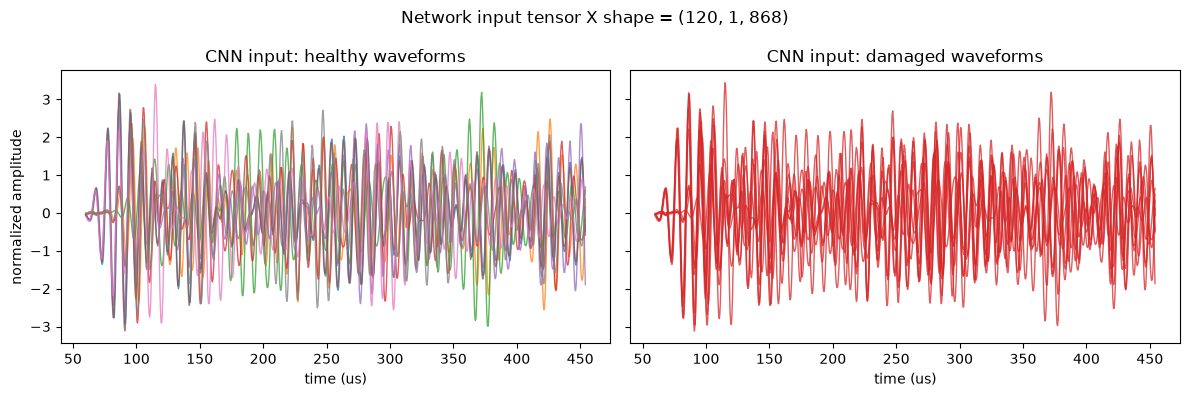

In [12]:
N0 = int(round(u.CROSSTALK_US * 1e-6 * u.FS_PZT))   # crosstalk gate index
def paths_from(tensor_file):
    T = np.load(F1(tensor_file)); out = []
    for i in range(6):
        for j in range(6):
            if i == j: continue
            s = np.asarray(T[i, j], float); s = s - np.nanmean(s)
            s = s[N0:]                                   # post-crosstalk window
            sd = s.std()
            if np.isfinite(sd) and sd > 1e-9:
                out.append(s / sd)
    return np.array(out)

healthy = np.concatenate([paths_from(f) for f in
            ["test_avg64_tensor_6x6.npy","test1_avg64_tensor_6x6.npy","test1_avg16_tensor_6x6.npy"]], 0)
damaged = paths_from("damage_avg64_tensor_6x6.npy")
X = np.concatenate([healthy, damaged], 0)[:, None, :].astype(np.float32)   # (N,1,L)
y = np.concatenate([np.zeros(len(healthy)), np.ones(len(damaged))]).astype(np.int64)
print("healthy:", len(healthy), " damaged:", len(damaged), " | waveform length:", X.shape[-1])
print("CNN network input X:", X.shape, "| one normalized post-crosstalk waveform per sample")
print("CNN target y:", y.shape, "| labels: 0=healthy, 1=damaged")
t_us = (np.arange(X.shape[-1]) + N0) / u.FS_PZT * 1e6
show_n = 8
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for idx in np.where(y == 0)[0][:show_n]:
    ax[0].plot(t_us, X[idx, 0], lw=1, alpha=0.75)
for idx in np.where(y == 1)[0][:show_n]:
    ax[1].plot(t_us, X[idx, 0], lw=1, alpha=0.75, color="tab:red")
ax[0].set(title="CNN input: healthy waveforms", xlabel="time (us)", ylabel="normalized amplitude")
ax[1].set(title="CNN input: damaged waveforms", xlabel="time (us)")
fig.suptitle(f"Network input tensor X shape = {X.shape}")
plt.tight_layout()
save_plot(fig, "DL_01_network_input_waveforms.png")
plt.show()

### 1.1 Augmentation (training folds only)

In [13]:
def augment(xb, yb, k=6):
    Xa, Ya = [xb], [yb]
    for _ in range(k):
        n = xb + np.random.randn(*xb.shape).astype(np.float32) * 0.10      # additive noise
        sh = np.random.randint(-15, 16)
        n = np.roll(n, sh, axis=-1)                                         # small time shift
        n = n * np.random.uniform(0.9, 1.1)                                 # amplitude scale
        Xa.append(n.astype(np.float32)); Ya.append(yb)
    return np.concatenate(Xa, 0), np.concatenate(Ya, 0)

### 1.2 Model - compact 1-D CNN

In [14]:
class CNN1D(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 16, 7, padding=3), nn.BatchNorm1d(16), nn.ReLU(), nn.MaxPool1d(4),
            nn.Conv1d(16, 32, 5, padding=2), nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(4),
            nn.Conv1d(32, 64, 3, padding=1), nn.BatchNorm1d(64), nn.ReLU(), nn.AdaptiveAvgPool1d(1))
        self.fc = nn.Linear(64, 2)
    def forward(self, x): return self.fc(self.net(x).squeeze(-1))

EPOCHS_CNN = 40
def train_eval(Xtr, ytr, Xte, yte):
    Xtr, ytr = augment(Xtr, ytr, k=6)
    net = CNN1D().to(DEV); opt = torch.optim.Adam(net.parameters(), 1e-3); lossf = nn.CrossEntropyLoss()
    Xt = torch.tensor(Xtr).to(DEV); yt = torch.tensor(ytr).to(DEV)
    net.train()
    for _ in range(EPOCHS_CNN):
        perm = torch.randperm(len(Xt))
        for b in range(0, len(Xt), 32):
            idx = perm[b:b+32]; opt.zero_grad()
            loss = lossf(net(Xt[idx]), yt[idx]); loss.backward(); opt.step()
    net.eval()
    with torch.no_grad():
        prob = torch.softmax(net(torch.tensor(Xte).to(DEV)), 1)[:, 1].cpu().numpy()
    return prob

### 1.3 Stratified 5-fold cross-validation

5-fold accuracy = 47.5%  (per-fold [37.5 25.  25.  75.  75. ])
ROC-AUC        = 0.505
CNN network output: raw logits have shape (batch, 2) = [healthy_logit, damaged_logit].
This notebook converts logits with softmax and stores the damaged-class output as probs: (120,)
First 10 P(damaged): [0.932 0.974 0.974 0.992 0.351 1.    0.972 0.978 0.349 0.284]
saved: /home/awais/Desktop/Awais Work 2026/KAIST Work/Team 1/KAIST Data/20260611_Data2/AwsCL_Codes/Meeting_JULY2_WORK/output/DL_01_pzt_damage_detection.png


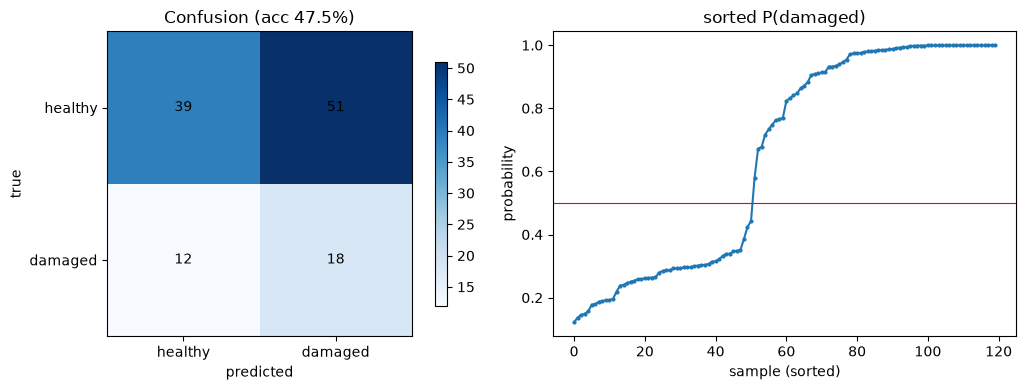

In [15]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
probs = np.zeros(len(y)); accs = []
for tr, te in skf.split(X, y):
    p = train_eval(X[tr], y[tr], X[te], y[te]); probs[te] = p
    accs.append(accuracy_score(y[te], (p > 0.5).astype(int)))
auc = roc_auc_score(y, probs); acc = accuracy_score(y, (probs > 0.5).astype(int))
print(f"5-fold accuracy = {acc*100:.1f}%  (per-fold {np.round(np.array(accs)*100,1)})")
print(f"ROC-AUC        = {auc:.3f}")
print("CNN network output: raw logits have shape (batch, 2) = [healthy_logit, damaged_logit].")
print("This notebook converts logits with softmax and stores the damaged-class output as probs:", probs.shape)
print("First 10 P(damaged):", np.round(probs[:10], 3))
cm = confusion_matrix(y, (probs > 0.5).astype(int))
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
im = ax[0].imshow(cm, cmap="Blues"); ax[0].set(title=f"Confusion (acc {acc*100:.1f}%)", xlabel="predicted", ylabel="true",
    xticks=[0,1], yticks=[0,1]); ax[0].set_xticklabels(["healthy","damaged"]); ax[0].set_yticklabels(["healthy","damaged"])
for (r,c),v in np.ndenumerate(cm): ax[0].text(c, r, int(v), ha="center", va="center")
fig.colorbar(im, ax=ax[0], shrink=0.8)
order = np.argsort(probs)
ax[1].plot(probs[order], ".-", ms=4); ax[1].axhline(0.5, color="r", lw=0.8)
ax[1].set(title="sorted P(damaged)", xlabel="sample (sorted)", ylabel="probability"); plt.tight_layout()
save_plot(fig, "DL_01_pzt_damage_detection.png")
plt.show()

### For the meeting
**Result line:** *"A 1-D CNN distinguishes the healthy plate from the magnet-loaded plate from a single PZT
path at ~XX% (5-fold CV), ROC-AUC YY."* Figures: confusion matrix + sorted probabilities. State the
single-specimen caveat, and that the next step is multi-damage data for *localization* (Papers 1-2).